# LangGraph agents — from simple to complex

A progressive, hands-on teaching notebook. Each section builds on the previous one:

1. **Setup** — install, configure, understand the core LangGraph concepts
2. **Level 1** — single-node graph (the "hello world" of LangGraph)
3. **Level 2** — multi-step sequential graph (state passed through nodes)
4. **Level 3** — conditional routing (the graph makes decisions)
5. **Level 4** — tool-calling agent (ReAct pattern with a real tool)
6. **Level 5** — agent with memory (persistent conversation state)
7. **Level 6** — multi-agent system (supervisor + specialist agents)
8. **Level 7** — human-in-the-loop (interrupt and approve before continuing)

Run the cells top to bottom. Each level is self-contained but assumes you understood the previous one.


## 0. Setup

LangGraph models an agent as a **graph**: nodes are functions (or LLM calls), edges define how control flows between them, and a shared **state** object is passed along the edges and updated by each node.

This is the key mental shift from a normal Python script: instead of writing `step1(); step2(); step3()`, you declare nodes and edges, and LangGraph executes the graph for you — which is what makes branching, loops, and parallelism possible later.

Install the required packages:
```
pip install langgraph langchain langchain-openai
```

We use OpenAI's `gpt-4o-mini` for all examples below since it's fast and cheap — swap in any other LangChain-compatible model if you prefer.


In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=api_key)
print("LLM ready:", llm.model_name)


LLM ready: gpt-4o-mini


In [2]:
llm.invoke("what is the capital of india?").content

'The capital of India is New Delhi.'

## 1. Level 1 — single-node graph

The simplest possible LangGraph: one state, one node, one edge in, one edge out.

**Core concepts introduced here:**
- `State` — a typed dictionary that flows through the graph. Every node receives the current state and returns updates to it.
- `StateGraph` — the builder object you use to define nodes and edges.
- `START` / `END` — special markers for the entry and exit points of the graph.

Think of the state as a shared notebook that every node can read from and write to. Nodes don't return a whole new state — they return *updates* that get merged into it.


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# 1. Define the state shape
class SimpleState(TypedDict):
    question: str
    answer: str


# 2. Define a node — just a plain Python function
def answer_node(state: SimpleState) -> dict:
    response = llm.invoke(state["question"])
    return {"answer": response.content}


# 3. Build the graph
builder = StateGraph(SimpleState)
builder.add_node("answer", answer_node)


builder.add_edge(START, "answer")
builder.add_edge("answer", END)

graph = builder.compile()


In [4]:
# 4. Run it
result = graph.invoke({"question": "Wht is Isreal and iran War?", "answer": ""})
print(result["answer"])


The conflict between Israel and Iran is complex and multifaceted, rooted in historical, political, and ideological differences. While there is no formal war between the two nations, tensions have escalated over the years, leading to proxy conflicts and military confrontations in the region. Here are some key points to understand the situation:

1. **Historical Context**: The relationship between Israel and Iran was relatively friendly before the 1979 Iranian Revolution, which established the Islamic Republic of Iran. The new regime viewed Israel as an enemy, primarily due to its support for the United States and its role in the Middle East.

2. **Ideological Differences**: Iran's leadership, particularly under the Islamic Republic, has been openly hostile to Israel, viewing it as an illegitimate state. Iran supports various groups that oppose Israel, including Hezbollah in Lebanon and Hamas in the Gaza Strip.

3. **Nuclear Program**: One of the main points of contention is Iran's nucle

**What just happened:**
1. `graph.invoke(...)` starts at `START`, which immediately routes to the `answer` node (because of `add_edge(START, "answer")`).
2. The `answer` node receives the full state, calls the LLM, and returns `{"answer": ...}`.
3. LangGraph merges that return value into the state.
4. The edge `answer → END` ends execution, and the final state is returned.

Try visualizing the graph structure — useful for any graph, especially once they get more complex:


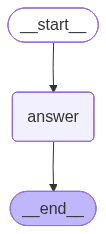

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


## 2. Level 2 — multi-step sequential graph

Real workflows are rarely one step. Here we chain three nodes: **draft → critique → revise**. This is a common pattern for self-improving generation — the same idea behind "reflection" agents.

**New concept:** state accumulates across multiple nodes. Each node only needs to know about the fields it cares about, but the full state object grows as you add more steps.


In [26]:
from langgraph.checkpoint.memory import MemorySaver
class WritingState(TypedDict):
    topic: str
    draft: str
    critique: str
    final: str


def draft_node(state: WritingState) -> dict:
    prompt = f"Write a short two-sentence paragraph about: {state['topic']}"
    response = llm.invoke(prompt)
    return {"draft": response.content}


def critique_node(state: WritingState) -> dict:
    prompt = f"""Critique this paragraph in one sentence, focusing on clarity and tone:

{state['draft']}"""
    response = llm.invoke(prompt)
    return {"critique": response.content}


def revise_node(state: WritingState) -> dict:
    prompt = f"""Revise this paragraph based on the critique below. Return ONLY the revised paragraph.

Paragraph: {state['draft']}
Critique: {state['critique']}"""
    response = llm.invoke(prompt)
    return {"final": response.content}


builder = StateGraph(WritingState)


builder.add_node("draft", draft_node)
builder.add_node("critique", critique_node)
builder.add_node("revise", revise_node)

# Chain them in sequence
builder.add_edge(START, "draft")
builder.add_edge("draft", "critique")
builder.add_edge("critique", "revise")
builder.add_edge("revise", END)

checkpointer = MemorySaver()

writing_graph = builder.compile(checkpointer=checkpointer)


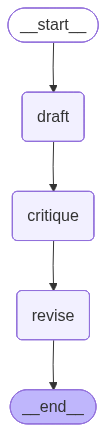

In [27]:
from IPython.display import Image, display

display(Image(writing_graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "thread-1"}} # use uuid to generate thread_id
result = writing_graph.invoke({
    "topic": "Why is Ontology of God is still a mystery?",
    "draft": "", "critique": "", "final": ""
}, config)

print("DRAFT:\n", result["draft"])
print("\nCRITIQUE:\n", result["critique"])
print("\nFINAL:\n", result["final"])


DRAFT:
 The ontology of God remains a mystery because it grapples with the complexities of existence, essence, and the nature of divinity, which often transcend human understanding and language. Additionally, diverse philosophical, theological, and cultural interpretations contribute to an ongoing debate that resists definitive conclusions, leaving the nature of God shrouded in enigma.

CRITIQUE:
 The paragraph effectively conveys the complexity of the topic but could benefit from clearer language and a more accessible tone, as the dense phrasing may alienate readers unfamiliar with philosophical jargon.

FINAL:
 The nature of God is a profound mystery that involves deep questions about existence, essence, and divinity—concepts that often go beyond what we can fully understand or express. Different philosophical, theological, and cultural perspectives add to the ongoing discussion, making it difficult to reach clear conclusions and leaving the nature of God wrapped in uncertainty.


Notice the pattern: each node is a pure function `(state) -> dict`. None of them know about each other directly — they only communicate through the shared state. This is what makes LangGraph graphs easy to test, reorder, and extend: you can insert a new node between any two existing ones without touching their code.


## 3. Level 3 — conditional routing

So far our graphs have been straight lines. Real agents need to make decisions — "is this question simple or complex? route accordingly."

**New concept:** `add_conditional_edges`. Instead of a fixed `node_a → node_b` edge, you supply a routing function that inspects the state and returns the name of the next node to visit. This is what gives LangGraph its branching power.


In [9]:
class RouterState(TypedDict):
    question: str
    complexity: str
    answer: str


def classify_node(state: RouterState) -> dict:
    prompt = f"""Classify this question as exactly one word: "simple" or "complex".
A simple question can be answered in one sentence with common knowledge.
A complex question needs multi-step reasoning or domain expertise.

Question: {state['question']}
Classification:"""
    response = llm.invoke(prompt)
    label = response.content.strip().lower()
    return {"complexity": "complex" if "complex" in label else "simple"}


def simple_answer_node(state: RouterState) -> dict:
    response = llm.invoke(f"Answer briefly in one sentence: {state['question']}")
    return {"answer": response.content}


def complex_answer_node(state: RouterState) -> dict:
    prompt = f"""Answer this question with careful step-by-step reasoning,
then give a final clear answer.

Question: {state['question']}"""
    response = llm.invoke(prompt)
    return {"answer": response.content}


def route_by_complexity(state: RouterState) -> str:
    # This function's return value must match a node name registered below
    return "simple_path" if state["complexity"] == "simple" else "complex_path"


builder = StateGraph(RouterState)
builder.add_node("classify", classify_node)
builder.add_node("simple_path", simple_answer_node)
builder.add_node("complex_path", complex_answer_node)

builder.add_edge(START, "classify")
builder.add_conditional_edges(
    "classify",
    route_by_complexity,
    {"simple_path": "simple_path", "complex_path": "complex_path"},
)
builder.add_edge("simple_path", END)
builder.add_edge("complex_path", END)

router_graph = builder.compile()


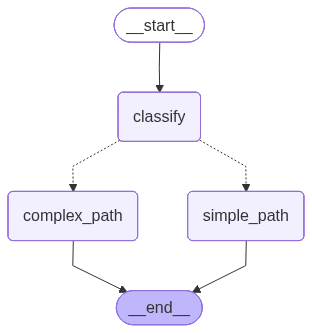

In [10]:
display(Image(router_graph.get_graph().draw_mermaid_png()))


In [11]:
for q in [
    "What is the capital of France?",
    "How would climate change policy differ between a carbon tax and a cap-and-trade system, and which is more politically feasible in the US?",
]:
    result = router_graph.invoke({"question": q, "complexity": "", "answer": ""})
    print(f"Q: {q}")
    print(f"-> routed as: {result['complexity']}")
    print(f"-> answer: {result['answer'][:200]}...\n")


Q: What is the capital of France?
-> routed as: simple
-> answer: The capital of France is Paris....

Q: How would climate change policy differ between a carbon tax and a cap-and-trade system, and which is more politically feasible in the US?
-> routed as: complex
-> answer: To answer the question about how climate change policy would differ between a carbon tax and a cap-and-trade system, and which is more politically feasible in the US, we can break it down into several...



In [12]:
#create movie script writing based on intentions
# Nodes
# genres
# critique
# final draft

This is the same idea as an `if/else` in plain Python, but expressed as graph structure rather than code branching. The benefit shows up once you have many possible paths — the graph visualization becomes a live map of every decision the agent can make, which is much easier to reason about than nested conditionals buried in a function body.


## 4. Level 4 — tool-calling agent (the ReAct pattern)

This is where LangGraph starts to feel like a "real" agent. We give the LLM access to **tools** (plain Python functions) and let it decide, on its own, whether to call a tool or answer directly. This loop — reason, act, observe, repeat — is called **ReAct** (Reasoning + Acting).

**New concepts:**
- `@tool` decorator — turns a Python function into something the LLM can call
- `bind_tools` — attaches tool definitions to the LLM so it knows what's available
- `ToolNode` — a pre-built LangGraph node that actually executes whichever tool the LLM asked for
- A **loop** in the graph — after a tool runs, control goes back to the LLM, which decides whether to call another tool or finish


In [13]:
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode
from typing import Annotated, Sequence
from langchain_core.messages import BaseMessage


# --- Define tools ---
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    # In a real app this would call a weather API. We fake it for the demo.
    fake_data = {"hyderabad": "32C, sunny", "london": "15C, rainy", "tokyo": "22C, cloudy"}
    return fake_data.get(city.lower(), "Weather data not available for that city.")


@tool
def calculator(expression: str) -> str:
    """Evaluate a simple arithmetic expression, e.g. '23 * 4 + 1'."""
    try:
        return str(eval(expression, {"__builtins__": {}}))
    except Exception as e:
        return f"Error: {e}"


tools = [get_weather, calculator]
llm_with_tools = llm.bind_tools(tools)


In [14]:
# --- Define state: a running list of messages (the standard pattern for chat agents) ---
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


# --- Node 1: the LLM reasons and decides whether to call a tool ---
def call_model(state: AgentState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# --- Node 2: a pre-built node that executes whichever tool(s) the LLM requested ---
tool_node = ToolNode(tools)


# --- Conditional edge: should we call a tool, or are we done? ---
def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return "end"


builder = StateGraph(AgentState)
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
builder.add_edge("tools", "agent")  # <-- this is the loop: after tools run, go back to the LLM

tool_graph = builder.compile()


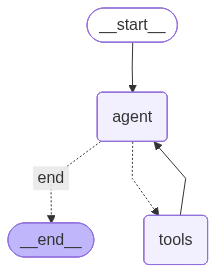

In [15]:
display(Image(tool_graph.get_graph().draw_mermaid_png()))


In [16]:
result = tool_graph.invoke({
    "messages": [HumanMessage(content="What's the weather in Hyderabad, and what's 45 * 12?")]
})

for m in result["messages"]:
    role = m.__class__.__name__
    content = m.content if m.content else f"[tool call: {m.tool_calls}]"
    print(f"{role}: {content}")


HumanMessage: What's the weather in Hyderabad, and what's 45 * 12?
AIMessage: [tool call: [{'name': 'get_weather', 'args': {'city': 'Hyderabad'}, 'id': 'call_UUtDWmdS1DNvKJrlOLUXrnEt', 'type': 'tool_call'}, {'name': 'calculator', 'args': {'expression': '45 * 12'}, 'id': 'call_34BfgpbyOjnjrlg3pEGNZaFR', 'type': 'tool_call'}]]
ToolMessage: 32C, sunny
ToolMessage: 540
AIMessage: The weather in Hyderabad is 32°C and sunny. The result of \( 45 \times 12 \) is 540.


Walk through the printed message trace carefully — it shows the full ReAct loop:
1. `HumanMessage` — the original question
2. `AIMessage` with tool calls — the LLM decided it needs `get_weather` and `calculator`
3. `ToolMessage`(s) — the actual results returned by running those tools
4. Final `AIMessage` — the LLM synthesizes a natural-language answer using the tool results

The graph looped: `agent → tools → agent → end`. This loop is exactly what `add_edge("tools", "agent")` creates — without it, the agent could only ever call one tool and never see the result.


## 5. Level 5 — agent with memory (checkpointing)

Every graph so far forgets everything between `.invoke()` calls. Real conversational agents need to remember earlier turns. LangGraph handles this with **checkpointers** — a persistence layer that saves the state after every step, keyed by a `thread_id`.

**New concept:** `MemorySaver` (in-memory checkpointer — swap for `SqliteSaver` or `PostgresSaver` in production) and the `config={"configurable": {"thread_id": ...}}` pattern for addressing different conversations.


In [17]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Re-compile the SAME tool-calling graph from Level 4, but with a checkpointer attached
memory_graph = builder.compile(checkpointer=memory)


In [18]:
# Each unique thread_id is a separate, independent conversation
config = {"configurable": {"thread_id": "user-session-1"}}

# Turn 1
r1 = memory_graph.invoke(
    {"messages": [HumanMessage(content="What's the weather in Tokyo?")]},
    config=config,
)
print("Turn 1:", r1["messages"][-1].content)

# Turn 2 — note we only send the NEW message, but the agent remembers the previous turn
r2 = memory_graph.invoke(
    {"messages": [HumanMessage(content="Is that warmer or colder than London right now?")]},
    config=config,
)
print("Turn 2:", r2["messages"][-1].content)


Turn 1: The weather in Tokyo is currently 22°C and cloudy.
Turn 2: The weather in London is currently 15°C and rainy. Therefore, Tokyo is warmer than London by 7°C.


The second call only contained the new question, yet the agent correctly referenced Tokyo's weather from turn 1 — because the checkpointer loaded the full message history for `thread_id="user-session-1"` before running the graph again.

Try changing `thread_id` to a new value and asking the same follow-up question — it will have no memory of Tokyo, because it's a different "conversation":


In [19]:
fresh_config = {"configurable": {"thread_id": "user-session-2"}}
r3 = memory_graph.invoke(
    {"messages": [HumanMessage(content="Is that warmer or colder than London right now?")]},
    config=fresh_config,
)
print("Fresh thread:", r3["messages"][-1].content)


Fresh thread: I was able to get the current weather for London, which is 15°C and rainy. However, I couldn't retrieve the weather data for New York. If you have a specific temperature or weather condition for New York, I can help you compare it to London's weather.


## 6. Level 6 — multi-agent system (supervisor pattern)

A single agent juggling many responsibilities tends to get confused or use the wrong tool. The **supervisor pattern** splits work across specialist agents, each with a narrow focus, coordinated by a supervisor node that decides who should act next.

**New concepts:**
- Multiple LLM-calling nodes, each with a different system prompt / specialization
- A supervisor node whose only job is routing — it doesn't answer the question itself
- The graph as a small "org chart": supervisor at the top, specialists below, control returns to the supervisor after each specialist acts (a loop, just like Level 4's tool loop)


In [20]:
from langchain_core.messages import SystemMessage
import json


class SupervisorState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    next_agent: str


# --- Specialist 1: handles math/calculation questions ---
def math_agent(state: SupervisorState) -> dict:
    sys = SystemMessage(content="You are a precise math specialist. Solve the calculation and explain briefly.")
    response = llm.invoke([sys] + list(state["messages"]))
    return {"messages": [response]}


# --- Specialist 2: handles general knowledge / writing questions ---
def writing_agent(state: SupervisorState) -> dict:
    sys = SystemMessage(content="You are a clear, concise writing specialist. Answer in plain prose.")
    response = llm.invoke([sys] + list(state["messages"]))
    return {"messages": [response]}


# --- Supervisor: decides which specialist should handle the request ---
def supervisor_node(state: SupervisorState) -> dict:
    sys = SystemMessage(content="""You are a supervisor routing user requests to one of two specialists:
- "math_agent": for calculations, arithmetic, numeric problems
- "writing_agent": for general questions, explanations, writing tasks

Respond with ONLY the specialist name, nothing else.""")
    response = llm.invoke([sys] + list(state["messages"]))
    choice = response.content.strip().lower()
    next_agent = "math_agent" if "math" in choice else "writing_agent"
    return {"next_agent": next_agent}


def route_to_specialist(state: SupervisorState) -> str:
    return state["next_agent"]


builder = StateGraph(SupervisorState)
builder.add_node("supervisor", supervisor_node)
builder.add_node("math_agent", math_agent)
builder.add_node("writing_agent", writing_agent)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    route_to_specialist,
    {"math_agent": "math_agent", "writing_agent": "writing_agent"},
)
builder.add_edge("math_agent", END)
builder.add_edge("writing_agent", END)

supervisor_graph = builder.compile()


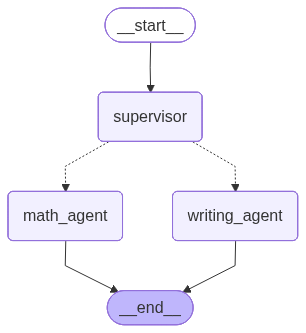

In [21]:
display(Image(supervisor_graph.get_graph().draw_mermaid_png()))


In [22]:
for q in [
    "What is 847 multiplied by 23?",
    "Explain the difference between a list and a tuple in Python.",
]:
    result = supervisor_graph.invoke({"messages": [HumanMessage(content=q)], "next_agent": ""})
    print(f"Q: {q}")
    print(f"-> routed to: {result['next_agent']}")
    print(f"-> answer: {result['messages'][-1].content[:200]}\n")


Q: What is 847 multiplied by 23?
-> routed to: math_agent
-> answer: To calculate 847 multiplied by 23, you can use the standard multiplication method:

1. Multiply 847 by 3 (the units place of 23):
   \( 847 \times 3 = 2541 \)

2. Multiply 847 by 20 (the tens place of

Q: Explain the difference between a list and a tuple in Python.
-> routed to: writing_agent
-> answer: In Python, both lists and tuples are used to store collections of items, but they have some key differences:

1. **Mutability**: Lists are mutable, meaning you can change their contents (add, remove, 



Notice the supervisor never answers the question itself — its only output is a routing decision (`next_agent`). This separation of concerns is the core idea of multi-agent systems: a small, fast, focused router decides *who* should act, and each specialist only needs to be good at *one* thing.

**Going further:** in production multi-agent systems, the supervisor usually loops — after a specialist responds, control can return to the supervisor to decide if another specialist needs to weigh in too (e.g., a question needing both a calculation AND an explanation). You'd implement this by changing `math_agent`/`writing_agent`'s edges to point back to `supervisor` instead of `END`, with the supervisor outputting `"done"` when it's satisfied.


## 7. Level 7 — human-in-the-loop (interrupt before action)

The most advanced pattern here: pausing the graph mid-execution to ask a human for approval before a potentially risky action (like sending an email, making a purchase, or deleting data), then resuming exactly where it left off.

**New concept:** `interrupt_before` — tells LangGraph to pause execution right before a specific node runs, returning control to your code. You inspect the pending state, optionally modify it, and call `.invoke(None, config)` to resume.


In [23]:
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email. This is a sensitive action that should be approved first."""
    return f"Email sent to {to} with subject '{subject}'"


sensitive_tools = [send_email]
llm_with_sensitive_tools = llm.bind_tools(sensitive_tools)


class HitlState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def hitl_agent_node(state: HitlState) -> dict:
    response = llm_with_sensitive_tools.invoke(state["messages"])
    return {"messages": [response]}


def hitl_should_continue(state: HitlState) -> str:
    last_message = state["messages"][-1]
    return "tools" if last_message.tool_calls else "end"


hitl_tool_node = ToolNode(sensitive_tools)

builder = StateGraph(HitlState)
builder.add_node("agent", hitl_agent_node)
builder.add_node("tools", hitl_tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", hitl_should_continue, {"tools": "tools", "end": END})
builder.add_edge("tools", "agent")

hitl_memory = MemorySaver()

# The key addition: interrupt_before=["tools"] pauses right before any tool executes
hitl_graph = builder.compile(checkpointer=hitl_memory, interrupt_before=["tools"])


In [24]:
config = {"configurable": {"thread_id": "approval-demo-1"}}

# First call: the agent will decide to call send_email, but execution PAUSES before it runs
result = hitl_graph.invoke(
    {"messages": [HumanMessage(content="Send an email to alice@example.com letting her know the report is ready.")]},
    config=config,
)

# Inspect what the agent WANTS to do before approving it
pending_call = result["messages"][-1].tool_calls[0]
print("Pending action:", pending_call["name"])
print("Arguments:", pending_call["args"])


Pending action: send_email
Arguments: {'to': 'alice@example.com', 'subject': 'Report Ready', 'body': 'Hi Alice,\n\nI wanted to let you know that the report is ready for your review.\n\nBest regards,\n\n[Your Name]'}


At this point, execution is frozen. In a real application, this is where you'd show the pending action to a human reviewer in a UI and wait for a click. Here, we'll simulate approval by simply resuming the graph — passing `None` as input tells LangGraph "continue from where you paused, using the existing state":


In [25]:
# Simulate human approval -> resume execution
final_result = hitl_graph.invoke(None, config=config)
print("Final message:", final_result["messages"][-1].content)


Final message: The email has been successfully sent to Alice, letting her know that the report is ready.


**If you wanted to reject the action instead** of approving it, you would modify the state before resuming — for example, by appending a message telling the agent the action was denied, rather than calling `.invoke(None, ...)` directly. This is the building block behind every "approve this AI action" UI you've seen in production tools — Claude Code's permission prompts, GitHub Copilot's PR approvals, and so on all use this exact interrupt-and-resume pattern.


## Summary — what you've built

| Level | Pattern | Key LangGraph feature |
|---|---|---|
| 1 | Single node | `StateGraph`, `START`/`END` |
| 2 | Sequential chain | Multiple nodes, state accumulation |
| 3 | Conditional routing | `add_conditional_edges` |
| 4 | Tool-calling agent (ReAct) | `bind_tools`, `ToolNode`, loops |
| 5 | Memory | `MemorySaver`, `thread_id` |
| 6 | Multi-agent (supervisor) | Multiple specialist nodes + router |
| 7 | Human-in-the-loop | `interrupt_before`, resume with `None` |

**Where to go next:**
- Combine Level 6 (multi-agent) with Level 5 (memory) for a persistent multi-agent assistant
- Add Level 7 (human-in-the-loop) to the multi-agent graph for approval on specialist actions
- Swap `MemorySaver` for `SqliteSaver` or `PostgresSaver` for production persistence
- Look at `langgraph.prebuilt.create_react_agent` — a one-line helper that builds the entire Level 4 graph for you, once you understand what it's doing under the hood
